<a href="https://colab.research.google.com/github/hugo1911/ProyectoICOP2/blob/master/ICOP2_Deteccion_de_planta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clasifiacion y deteccion de plantas saludables**

---



Descarga del data set https://www.kaggle.com/datasets/rashikrahmanpritom/plant-disease-recognition-dataset

In [1]:
#Libreria para descargar el dataset usando API
!pip install kagglehub -q

In [2]:
import os

#token que te da kaggle para descargar el data set
os.environ["KAGGLE_API_TOKEN"] = "KGAT_f02f85a2b7d40ec71deaf7bf6c3258c3"


import kagglehub
path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")
print(path)

Using Colab cache for faster access to the 'plant-disease-recognition-dataset' dataset.
/kaggle/input/plant-disease-recognition-dataset


In [3]:
# ya que el dataset tiene Rutas diferentes se busca la estructura real del dataset
base = os.path.join(path, '1')

TRAIN_DIR = os.path.join(base, 'Train', 'Train')
VAL_DIR   = os.path.join(base, 'Validation', 'Validation')
TEST_DIR  = os.path.join(base, 'Test', 'Test')

for name, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    status = 'Existe' if os.path.exists(d) else 'No existe'
    print(f"{status} {name}: {d}")

No existe Train: /kaggle/input/plant-disease-recognition-dataset/1/Train/Train
No existe Val: /kaggle/input/plant-disease-recognition-dataset/1/Validation/Validation
No existe Test: /kaggle/input/plant-disease-recognition-dataset/1/Test/Test


## 1. EDA

In [4]:
import torch
print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

PyTorch version: 2.10.0+cpu
Dispositivo: cpu


In [5]:
import os


if os.path.exists('/kaggle/input'):
    # Entorno Kaggle
    base = '/kaggle/input/plant-disease-recognition-dataset'
else:
    # Entorno Colab
    base = os.path.join(path, '1')

# Buscar las carpetas Train/Validation/Test
def find_dir(base, names):
    for name in names:
        candidate = os.path.join(base, name, name)
        if os.path.exists(candidate):
            return candidate
        candidate = os.path.join(base, name)
        if os.path.exists(candidate):
            return candidate
    return None

TRAIN_DIR = find_dir(base, ['Train', 'train', 'training'])
VAL_DIR   = find_dir(base, ['Validation', 'validation', 'val'])
TEST_DIR  = find_dir(base, ['Test', 'test'])

for name, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    status = 'Existe' if d and os.path.exists(d) else 'No existe'
    print(f"{status} {name}: {d}")

Existe Train: /kaggle/input/plant-disease-recognition-dataset/Train/Train
Existe Val: /kaggle/input/plant-disease-recognition-dataset/Validation/Validation
Existe Test: /kaggle/input/plant-disease-recognition-dataset/Test/Test


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import seaborn as sns

In [7]:
# Clases disponibles
classes = sorted(os.listdir(TRAIN_DIR))
num_classes = len(classes)
print(f"Total de clases: {num_classes}")
for c in classes:
    print(c)

Total de clases: 3
Healthy
Powdery
Rust


         Train  Validacion  Test
Healthy    458          20    50
Powdery    430          20    50
Rust       434          20    50

Total — Train: 1322 | Val: 60 | Test: 150


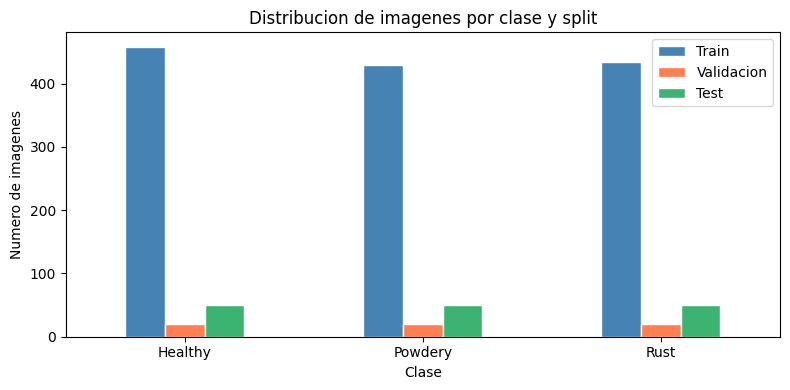

In [8]:


# Conteo de imagenes por clase
def count_images(base_dir):
    counts = {}
    for cls in sorted(os.listdir(base_dir)):
        cls_path = os.path.join(base_dir, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

df_counts = pd.DataFrame({'Train': train_counts, 'Validacion': val_counts, 'Test': test_counts})
print(df_counts)
print(f"\nTotal — Train: {df_counts['Train'].sum()} | Val: {df_counts['Validacion'].sum()} | Test: {df_counts['Test'].sum()}")

# Grafica de distribución
df_counts.plot(kind='bar', figsize=(8, 4), edgecolor='white', color=['steelblue','coral','mediumseagreen'])
plt.title('Distribucion de imagenes por clase y split')
plt.ylabel('Numero de imagenes')
plt.xlabel('Clase')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

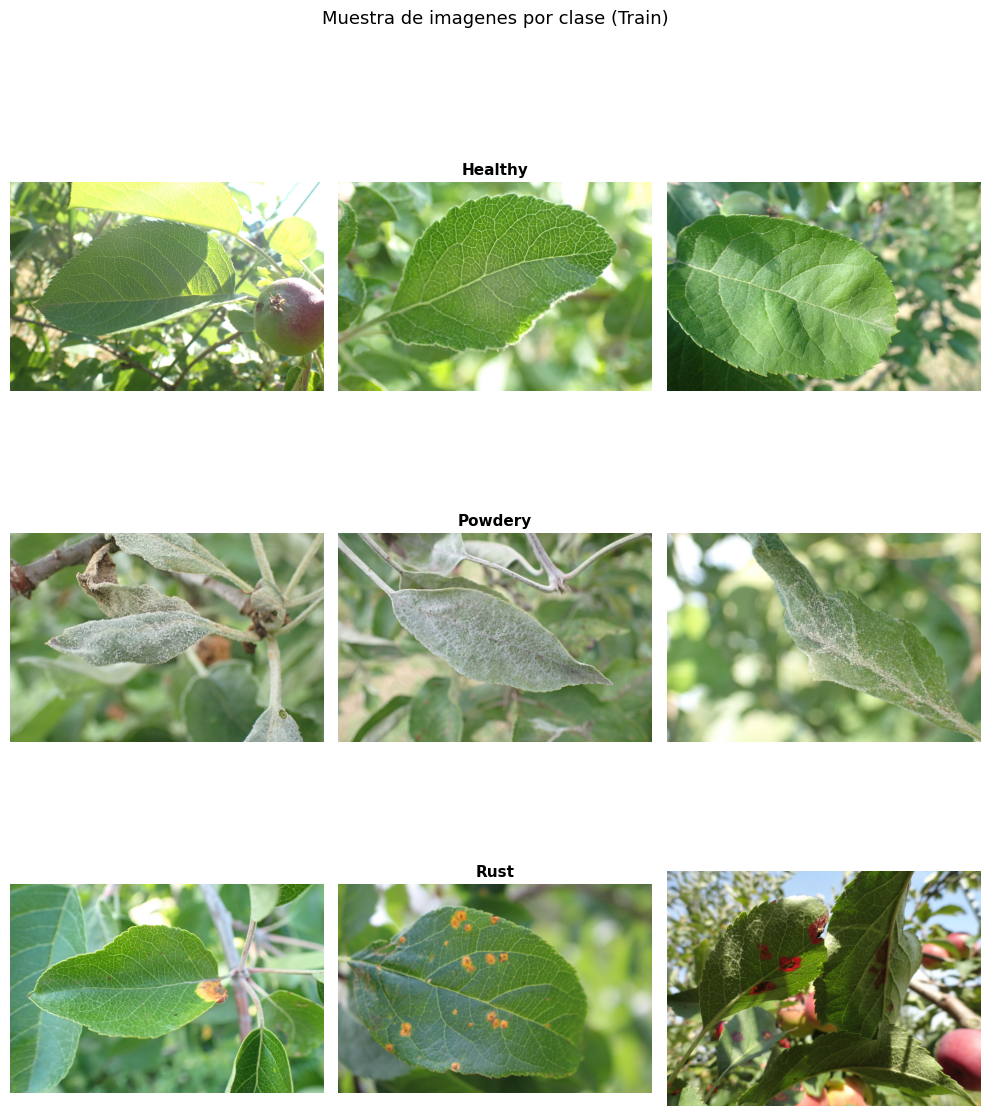

In [9]:
import matplotlib.image as mpimg

# Visualizacion de 3 imagenes por clase
fig, axes = plt.subplots(len(classes), 3, figsize=(10, 4 * len(classes)))
for row, cls in enumerate(classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs_files = os.listdir(cls_path)[:3]
    for col, fname in enumerate(imgs_files):
        img = mpimg.imread(os.path.join(cls_path, fname))
        axes[row][col].imshow(img)
        axes[row][col].set_title(f"{cls}" if col == 1 else "", fontsize=11, fontweight='bold')
        axes[row][col].axis('off')
plt.suptitle('Muestra de imagenes por clase (Train)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Ancho  — min: 2592, max: 5184, promedio: 3986
Alto   — min: 1728, max: 3456, promedio: 2720


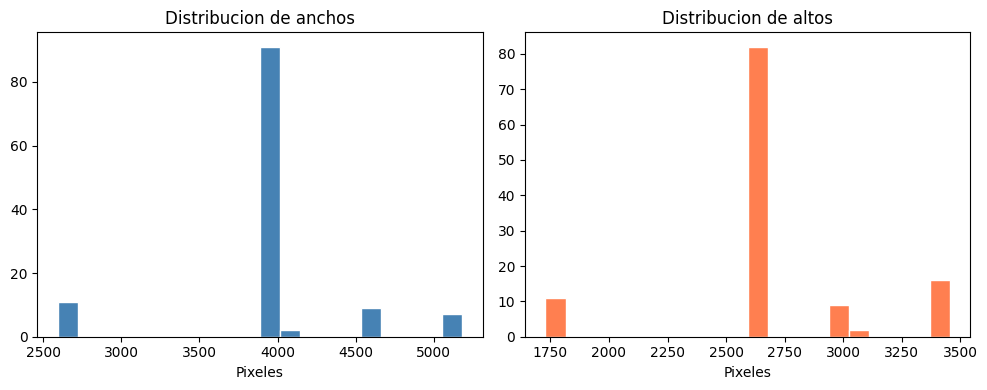

In [10]:
from PIL import Image


# Dimensiones de las imagenes
widths, heights = [], []
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path)[:40]:
        try:
            img = Image.open(os.path.join(cls_path, fname))
            widths.append(img.width)
            heights.append(img.height)
        except:
            pass

print(f"Ancho  — min: {min(widths)}, max: {max(widths)}, promedio: {np.mean(widths):.0f}")
print(f"Alto   — min: {min(heights)}, max: {max(heights)}, promedio: {np.mean(heights):.0f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(widths,  bins=20, color='steelblue', edgecolor='white')
ax1.set_title('Distribucion de anchos')
ax1.set_xlabel('Pixeles')
ax2.hist(heights, bins=20, color='coral', edgecolor='white')
ax2.set_title('Distribucion de altos')
ax2.set_xlabel('Pixeles')
plt.tight_layout()
plt.show()


## 2. Preprocesamiento

In [11]:
from torchvision import datasets, transforms, models

IMG_SIZE   = 224
BATCH_SIZE = 32

# Transformaciones para entrenamiento con data augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),


    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformaciones para validacion y test sin augmentation
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transformaciones definidas ")
print("\nTrain transforms:", train_transforms)
print("\nVal/Test transforms:", val_transforms)



Transformaciones definidas 

Train transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val/Test transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [12]:
# Cargar los tres splits
# El dataset ya viene dividido en Train / Validation / Test
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=VAL_DIR,   transform=val_transforms)
test_dataset  = datasets.ImageFolder(root=TEST_DIR,  transform=val_transforms)

class_names = train_dataset.classes
num_classes  = len(class_names)

print(f"Clases ({num_classes}): {class_names}")
print(f"Train:      {len(train_dataset)} imagenes")
print(f"Validacion: {len(val_dataset)} imagenes")
print(f"Test:       {len(test_dataset)} imagenes")

Clases (3): ['Healthy', 'Powdery', 'Rust']
Train:      1322 imagenes
Validacion: 60 imagenes
Test:       150 imagenes


In [13]:
from torch.utils.data import DataLoader

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Verificar un batch
imgs, labels = next(iter(train_loader))
print(f"Shape de un batch: {imgs.shape}")
print(f"Rango de valores:  [{imgs.min():.2f}, {imgs.max():.2f}]")
print(f"Labels ejemplo:    {labels[:8].tolist()}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape de un batch: torch.Size([32, 3, 224, 224])
Rango de valores:  [-2.12, 2.64]
Labels ejemplo:    [1, 1, 2, 1, 0, 2, 1, 2]


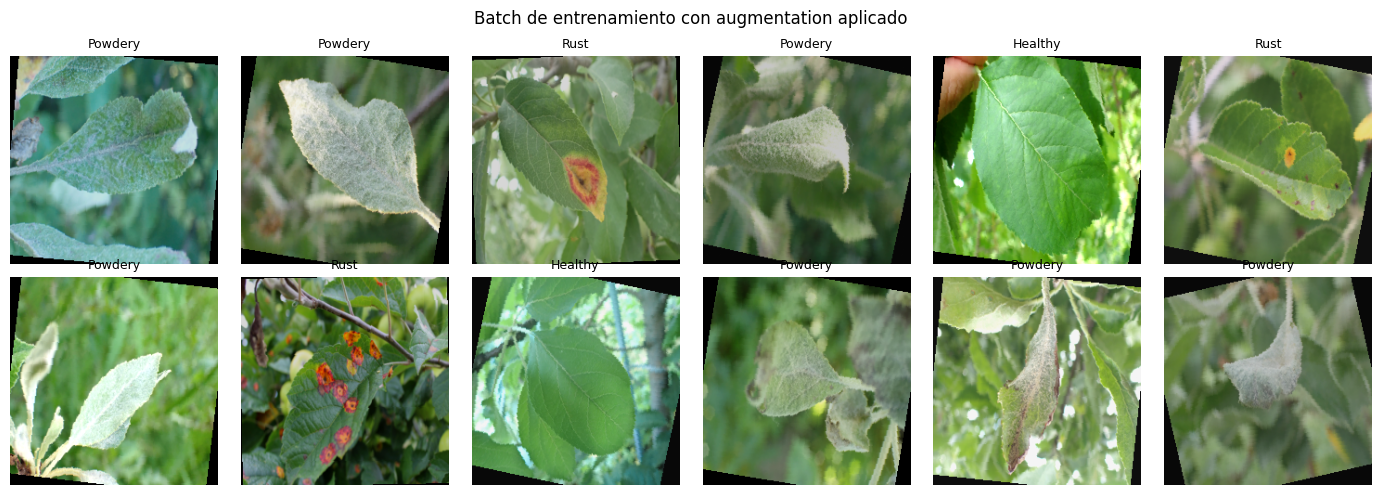

In [14]:
# Visualiazccion de un batch con augmentation aplicado
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

n_show = min(12, len(imgs))
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, ax in enumerate(axes.flatten()[:n_show]):
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Batch de entrenamiento con augmentation aplicado', fontsize=12)
plt.tight_layout()
plt.show()


## 3. Entrenamiento del modelo

Se haran tres arquitecturas distintas:
- **Modelo 1**: CNN personalizada entrenada desde cero
- **Modelo 2**: ResNet-18
- **Modelo 3**: EfficientNet-B0

In [15]:
import torch.optim as optim


def train_model(model, train_loader, val_loader, num_epochs=20, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # Validacion
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * imgs.size(0)
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total   += labels.size(0)

        val_loss = running_loss / total
        val_acc  = correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        scheduler.step()

        print(f"Epoch {epoch+1:02d}/{num_epochs} | "
              f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

    return model, history

# Grafica de salida
def plot_learning_curves(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history['train_loss'], label='Train',      color='steelblue')
    ax1.plot(epochs, history['val_loss'],   label='Validacion', color='coral')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(epochs, history['train_acc'], label='Train',      color='steelblue')
    ax2.plot(epochs, history['val_acc'],   label='Validacion', color='coral')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

print("Funciones de entrenamiento listas")

Funciones de entrenamiento listas


### Modelo 1 — CNN personalizada

In [16]:
import torch.nn as nn

class CustomCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1 3 a 32 canales
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 2 32 a 64 canales
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 3 64 a 128 canales
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model1 = CustomCNN(num_classes)
total_params = sum(p.numel() for p in model1.parameters())
print(f"CustomCNN parametros totales: {total_params:,}")

CustomCNN parametros totales: 619,011


  ENTRENANDO: Modelo 1 — CustomCNN
Epoch 01/20 | Train loss: 0.8349  acc: 0.6324 | Val loss: 0.6815  acc: 0.7167
Epoch 02/20 | Train loss: 0.5062  acc: 0.7988 | Val loss: 0.3741  acc: 0.8333
Epoch 03/20 | Train loss: 0.4047  acc: 0.8563 | Val loss: 0.3048  acc: 0.9000
Epoch 04/20 | Train loss: 0.3091  acc: 0.8918 | Val loss: 0.3764  acc: 0.8167
Epoch 05/20 | Train loss: 0.2786  acc: 0.9092 | Val loss: 0.2168  acc: 0.9333
Epoch 06/20 | Train loss: 0.2175  acc: 0.9266 | Val loss: 0.1812  acc: 0.9333
Epoch 07/20 | Train loss: 0.2640  acc: 0.9115 | Val loss: 0.2398  acc: 0.9167
Epoch 08/20 | Train loss: 0.1874  acc: 0.9357 | Val loss: 0.1524  acc: 0.9333
Epoch 09/20 | Train loss: 0.1444  acc: 0.9523 | Val loss: 0.1316  acc: 0.9500
Epoch 10/20 | Train loss: 0.1590  acc: 0.9493 | Val loss: 0.1042  acc: 0.9500
Epoch 11/20 | Train loss: 0.1414  acc: 0.9539 | Val loss: 0.1167  acc: 0.9500
Epoch 12/20 | Train loss: 0.1408  acc: 0.9516 | Val loss: 0.1091  acc: 0.9333
Epoch 13/20 | Train loss: 0.1

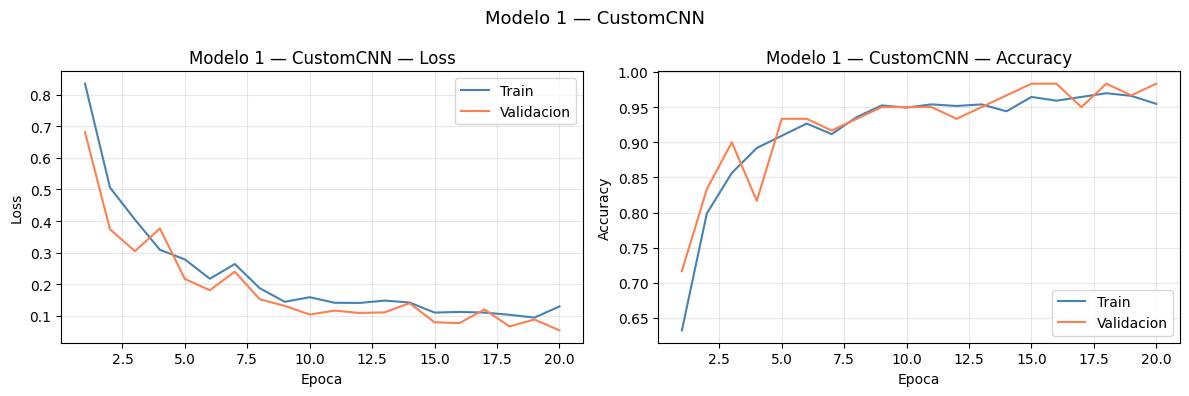

In [17]:
NUM_EPOCHS = 20

print("  ENTRENANDO: Modelo 1 — CustomCNN")

model1, history1 = train_model(model1, train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=1e-3)
plot_learning_curves(history1, 'Modelo 1 — CustomCNN')